# E-Commerce Business Process Optimization
## BA Portfolio Project — Python Analysis
**Dataset:** Olist Brazilian E-Commerce | Kaggle  
**Author:** Samadhi Pathirathna 
**Date:** 2026  

### Contents
1. Setup & Data Loading
2. Exploratory Data Analysis
3. RFM Customer Segmentation
4. Cohort Analysis
5. Funnel Analysis


In [1]:
# ============================================================
# SECTION 1: SETUP & IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# Global chart styling
sns.set_theme(style="whitegrid",palette="muted")
plt.rcParams['figure.figsize']=(12,6)
plt.rcParams['font.size']=11
plt.rcParams['axes.titlesize']=14
plt.rcParams['axes.titleweight']='bold'

print("Setup complete. Libraries imported and styling configured.")


Setup complete. Libraries imported and styling configured.


In [2]:

# ============================================================
# LOAD ALL DATASETS
# ============================================================

# Update this path to your actual folder location
import os
data_path = r"C:\Users\Hp\OneDrive\Desktop\BA_Ecommerce_Project\Raw_Data"

# Helper function to load with status confirmation
def load_csv(filename):
    filepath = os.path.join(data_path, filename)
    df = pd.read_csv(filepath)
    print(f"✓ {filename:<50} {df.shape[0]:>8,} rows  {df.shape[1]:>3} columns")
    return df

print("Loading datasets...\n")
orders          = load_csv("olist_orders_dataset.csv")
order_items     = load_csv("olist_order_items_dataset.csv")
customers       = load_csv("olist_customers_dataset.csv")
payments        = load_csv("olist_order_payments_dataset.csv")
products        = load_csv("olist_products_dataset.csv")
reviews         = load_csv("olist_order_reviews_dataset.csv")
category_trans  = load_csv("product_category_name_translation.csv")
print("\n✓ All datasets loaded successfully")


Loading datasets...

✓ olist_orders_dataset.csv                             99,441 rows    8 columns
✓ olist_order_items_dataset.csv                       112,650 rows    7 columns
✓ olist_customers_dataset.csv                          99,441 rows    5 columns
✓ olist_order_payments_dataset.csv                    103,886 rows    5 columns
✓ olist_products_dataset.csv                           32,951 rows    9 columns
✓ olist_order_reviews_dataset.csv                      99,224 rows    7 columns
✓ product_category_name_translation.csv                    71 rows    2 columns

✓ All datasets loaded successfully


In [3]:
# ============================================================
# DATA CLEANING & MERGING
# ============================================================

# --- 1. Convert date columns ---
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# --- 2. Filter to delivered orders only ---
orders_clean = orders[orders['order_status'] == 'delivered'].copy()
orders_clean = orders_clean.dropna(subset=[
    'order_delivered_customer_date',
    'order_approved_at'
])

# --- 3. Add calculated columns ---
orders_clean['delivery_days'] = (
    orders_clean['order_delivered_customer_date'] -
    orders_clean['order_purchase_timestamp']
).dt.days

orders_clean['purchase_month'] = (
    orders_clean['order_purchase_timestamp'].dt.to_period('M')
)

orders_clean['purchase_year'] = (
    orders_clean['order_purchase_timestamp'].dt.year
)

# --- 4. Add English category names to products ---
products_eng = products.merge(
    category_trans,
    on='product_category_name',
    how='left'
)

# --- 5. Aggregate payments (one row per order) ---
payments_agg = (
    payments.groupby('order_id')['payment_value']
    .sum()
    .reset_index()
    .rename(columns={'payment_value': 'total_payment'})
)

# --- 6. Build master dataframe ---
master = (
    orders_clean
    .merge(customers, on='customer_id', how='left')
    .merge(order_items, on='order_id', how='left')
    .merge(products_eng[['product_id',
           'product_category_name_english']],
           on='product_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
    .merge(reviews[['order_id','review_score']],
           on='order_id', how='left')
)

print(f"✓ Master dataframe built")
print(f"  Rows    : {master.shape[0]:,}")
print(f"  Columns : {master.shape[1]}")
print(f"\nColumn list:")
for col in master.columns:
    print(f"  - {col}")

✓ Master dataframe built
  Rows    : 110,817
  Columns : 24

Column list:
  - order_id
  - customer_id
  - order_status
  - order_purchase_timestamp
  - order_approved_at
  - order_delivered_carrier_date
  - order_delivered_customer_date
  - order_estimated_delivery_date
  - delivery_days
  - purchase_month
  - purchase_year
  - customer_unique_id
  - customer_zip_code_prefix
  - customer_city
  - customer_state
  - order_item_id
  - product_id
  - seller_id
  - shipping_limit_date
  - price
  - freight_value
  - product_category_name_english
  - total_payment
  - review_score


## Section 2: Exploratory Data Analysis
Understanding the shape and quality of our data before deep analysis.

In [4]:
# ============================================================
# SECTION 2: EXPLORATORY DATA ANALYSIS
# ============================================================

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\nDate range of orders:")
print(f"  From : {orders_clean['order_purchase_timestamp'].min().date()}")
print(f"  To   : {orders_clean['order_purchase_timestamp'].max().date()}")

print(f"\nRevenue summary:")
print(f"  Total revenue    : R$ {payments_agg['total_payment'].sum():>12,.2f}")
print(f"  Avg order value  : R$ {payments_agg['total_payment'].mean():>12,.2f}")
print(f"  Max order value  : R$ {payments_agg['total_payment'].max():>12,.2f}")

print(f"\nDelivery performance:")
print(f"  Avg delivery days : {orders_clean['delivery_days'].mean():.1f}")
print(f"  Min delivery days : {orders_clean['delivery_days'].min()}")
print(f"  Max delivery days : {orders_clean['delivery_days'].max()}")

print(f"\nCustomer satisfaction:")
print(f"  Avg review score  : {master['review_score'].mean():.2f} / 5.0")
print(f"  % 5-star reviews  : {(master['review_score']==5).mean()*100:.1f}%")
print(f"  % 1-star reviews  : {(master['review_score']==1).mean()*100:.1f}%")

DATASET OVERVIEW

Date range of orders:
  From : 2016-03-10
  To   : 2018-12-08

Revenue summary:
  Total revenue    : R$ 16,008,872.12
  Avg order value  : R$       160.99
  Max order value  : R$    13,664.08

Delivery performance:
  Avg delivery days : 12.6
  Min delivery days : -334
  Max delivery days : 688

Customer satisfaction:
  Avg review score  : 4.08 / 5.0
  % 5-star reviews  : 57.1%
  % 1-star reviews  : 11.3%


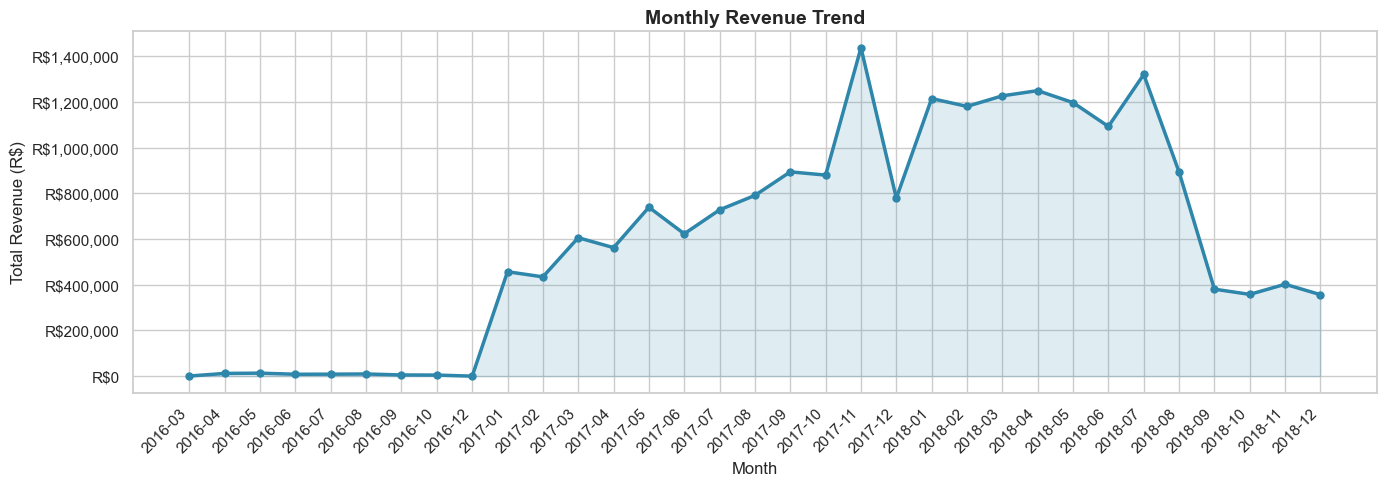

✓ Chart saved as monthly_revenue.png


In [7]:
import matplotlib.ticker as mticker  

# Monthly revenue trend chart
monthly_revenue = (
    master.groupby('purchase_month')['total_payment']
    .sum()
    .reset_index()
)
monthly_revenue['purchase_month'] = (
    monthly_revenue['purchase_month'].astype(str)
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_revenue['purchase_month'],
        monthly_revenue['total_payment'],
        color='#2E86AB', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(range(len(monthly_revenue)),
                monthly_revenue['total_payment'],
                alpha=0.15, color='#2E86AB')
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (R$)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'R${x:,.0f}')
)
plt.xticks(range(len(monthly_revenue)),
           monthly_revenue['purchase_month'],
           rotation=45, ha='right')
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved as monthly_revenue.png")

## Section 3: RFM Customer Segmentation

RFM stands for:
- **Recency** — How recently did the customer purchase?
- **Frequency** — How often do they purchase?
- **Monetary** — How much do they spend?

This segments customers into groups for targeted marketing strategy.

In [9]:
from datetime import datetime, timedelta  # ← add this line

# ============================================================
# SECTION 3: RFM CUSTOMER SEGMENTATION
# ============================================================

# Reference date = day after last order in dataset
reference_date = orders_clean['order_purchase_timestamp'].max() + timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

# Build RFM table - one row per customer
rfm = (
    master.groupby('customer_unique_id')
    .agg(
        last_purchase = ('order_purchase_timestamp', 'max'),
        frequency     = ('order_id',                 'nunique'),
        monetary      = ('total_payment',             'sum')
    )
    .reset_index()
)

# Calculate recency in days
rfm['recency'] = (
    reference_date - rfm['last_purchase']
).dt.days

# Drop the date column (no longer needed)
rfm = rfm.drop(columns=['last_purchase'])

print(f"\nRFM table built: {rfm.shape[0]:,} unique customers")
print(f"\nRFM Summary:")
print(rfm[['recency','frequency','monetary']].describe().round(2))

Reference date: 2018-12-09

RFM table built: 93,337 unique customers

RFM Summary:
        recency  frequency   monetary
count  93337.00   93337.00   93337.00
mean     333.76       1.03     212.98
std      176.60       0.21     646.29
min        1.00       1.00       0.00
25%      193.00       1.00      63.83
50%      316.00       1.00     113.14
75%      465.00       1.00     202.63
max     1004.00      15.00  109312.64


In [10]:
# Assign RFM scores 1-5 using quintiles
# Recency: lower days = better = score 5
# Frequency & Monetary: higher = better = score 5

rfm['R_score'] = pd.qcut(rfm['recency'],
                          q=5,
                          labels=[5,4,3,2,1])  # reversed: recent = 5

rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          q=5,
                          labels=[1,2,3,4,5])

rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),
                          q=5,
                          labels=[1,2,3,4,5])

# Convert to integer
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

# Calculate combined RFM score
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Assign segment labels based on scores
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost Customers'
    elif m >= 4 and f <= 2:
        return 'High Spenders'
    else:
        return 'Potential Loyalists'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

# Summary of segments
segment_summary = (
    rfm.groupby('segment')
    .agg(
        customer_count = ('customer_unique_id', 'count'),
        avg_recency    = ('recency',             'mean'),
        avg_frequency  = ('frequency',           'mean'),
        avg_monetary   = ('monetary',            'mean'),
        total_revenue  = ('monetary',            'sum')
    )
    .round(2)
    .sort_values('total_revenue', ascending=False)
)

print("RFM SEGMENT SUMMARY")
print("=" * 70)
print(segment_summary.to_string())

RFM SEGMENT SUMMARY
                     customer_count  avg_recency  avg_frequency  avg_monetary  total_revenue
segment                                                                                     
At Risk                       22243       514.34           1.05        214.88     4779537.66
Loyal Customers               14158       236.80           1.05        270.77     3833567.91
High Spenders                  8623       450.11           1.00        418.34     3607372.68
New Customers                 14921       161.98           1.00        204.16     3046323.37
Champions                      6444       160.93           1.19        442.56     2851881.24
Potential Loyalists           20691       280.49           1.00         67.96     1406255.72
Lost Customers                 6257       514.68           1.00         56.50      353545.93


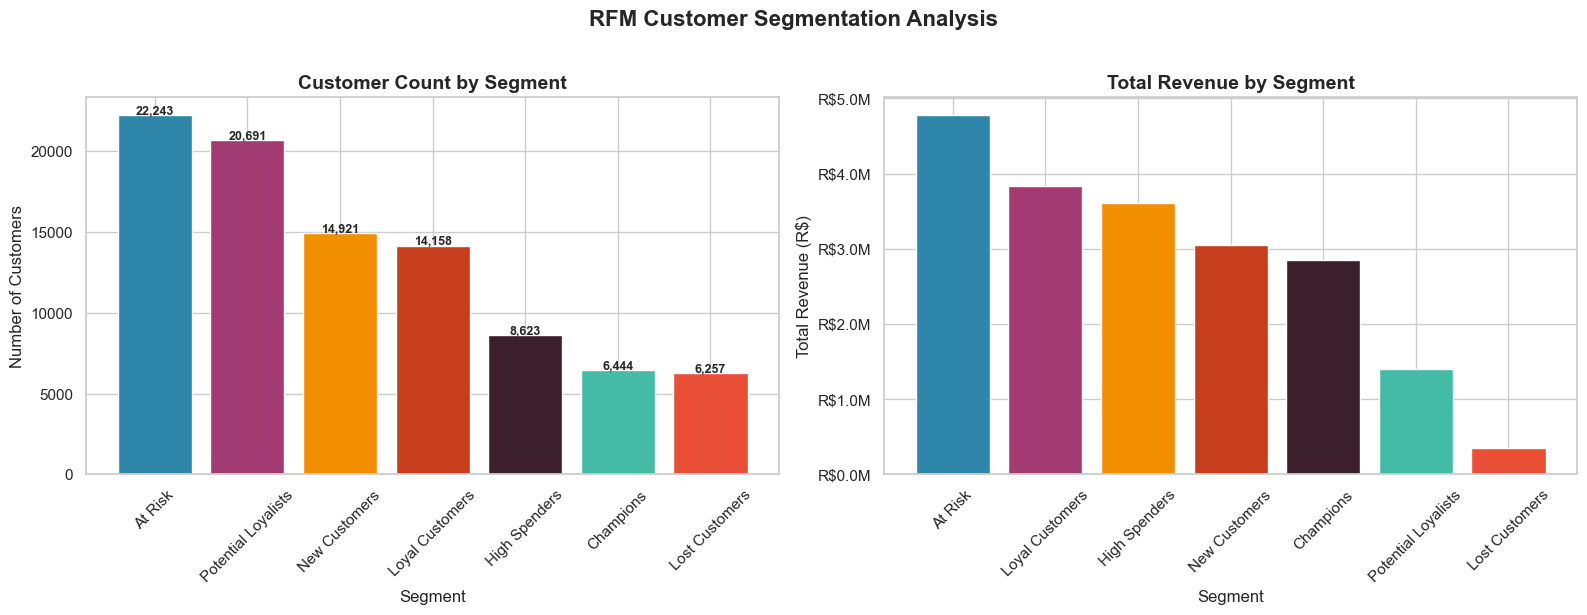

✓ Chart saved as rfm_segmentation.png


In [11]:
# Visualise RFM segments
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 - Customer count by segment
segment_counts = rfm['segment'].value_counts()
colors = ['#2E86AB','#A23B72','#F18F01','#C73E1D',
          '#3B1F2B','#44BBA4','#E94F37']
axes[0].bar(segment_counts.index, segment_counts.values,
            color=colors[:len(segment_counts)])
axes[0].set_title('Customer Count by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(segment_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center',
                 fontsize=9, fontweight='bold')

# Chart 2 - Total revenue by segment
rev_by_segment = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)
axes[1].bar(rev_by_segment.index, rev_by_segment.values,
            color=colors[:len(rev_by_segment)])
axes[1].set_title('Total Revenue by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Total Revenue (R$)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'R${x/1e6:.1f}M')
)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('RFM Customer Segmentation Analysis', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved as rfm_segmentation.png")

## Section 4: Cohort Analysis

A cohort is a group of customers who made their first purchase in the same month.

We track what percentage of each cohort comes back to buy again in later months.

**Business question: Are we retaining customers over time?**

How to read the heatmap:
- Each ROW = a group of customers who first bought in that month
- Each COLUMN = months after their first purchase (0 = first month, 1 = next month)
- The NUMBER = % of that cohort who came back to buy in that month
- Dark colour = low retention, Light colour = high retention

In [12]:
# ============================================================
# SECTION 4: COHORT ANALYSIS
# ============================================================

# ---- STEP 1: Get one row per customer per order ----
# We only need customer ID and when they ordered
cohort_data = master[['customer_unique_id', 'order_purchase_timestamp']].copy()

# Remove duplicate rows (same customer, same timestamp)
cohort_data = cohort_data.drop_duplicates()

# ---- STEP 2: Convert timestamp to month (we don't need exact dates) ----
# Example: 2018-03-15 becomes 2018-03
cohort_data['order_month'] = cohort_data['order_purchase_timestamp'].dt.to_period('M')

# ---- STEP 3: Find each customer's FIRST purchase month ----
# This is their "cohort" - the month they joined
first_purchase = (
    cohort_data
    .groupby('customer_unique_id')['order_month']
    .min()  # earliest month = first purchase
    .reset_index()
    .rename(columns={'order_month': 'cohort_month'})
)

# ---- STEP 4: Add cohort month back to main data ----
cohort_data = cohort_data.merge(first_purchase, on='customer_unique_id', how='left')

# ---- STEP 5: Calculate how many months after first purchase each order was ----
# Month 0 = first purchase, Month 1 = one month later, etc.
cohort_data['months_since_first'] = (
    (cohort_data['order_month'].dt.year  - cohort_data['cohort_month'].dt.year) * 12 +
    (cohort_data['order_month'].dt.month - cohort_data['cohort_month'].dt.month)
)

# ---- STEP 6: Count unique customers per cohort per month ----
cohort_counts = (
    cohort_data
    .groupby(['cohort_month', 'months_since_first'])['customer_unique_id']
    .nunique()
    .reset_index()
)
cohort_counts.columns = ['cohort_month', 'months_since_first', 'num_customers']

# ---- STEP 7: Reshape into a matrix (cohorts as rows, months as columns) ----
cohort_matrix = cohort_counts.pivot_table(
    index='cohort_month',
    columns='months_since_first',
    values='num_customers'
)

# ---- STEP 8: Calculate retention rate ----
# Divide each month's count by Month 0 count (the starting cohort size)
cohort_size = cohort_matrix[0]  # column 0 = number who first purchased that month
retention_matrix = cohort_matrix.divide(cohort_size, axis=0).round(3) * 100

# ---- STEP 9: Keep only first 6 months (enough to see the trend clearly) ----
retention_matrix = retention_matrix.iloc[:, :6]

# ---- Convert index to string for cleaner display ----
retention_matrix.index = retention_matrix.index.astype(str)

print("✓ Cohort retention matrix built successfully")
print(f"  Number of cohorts : {len(retention_matrix)}")
print(f"  Months tracked    : {retention_matrix.shape[1]}")
print(f"\nFirst 5 rows of retention matrix:")
print(retention_matrix.head().round(1))

✓ Cohort retention matrix built successfully
  Number of cohorts : 33
  Months tracked    : 6

First 5 rows of retention matrix:
months_since_first      0    1   2   3   4   5
cohort_month                                  
2016-03             100.0  NaN NaN NaN NaN NaN
2016-04             100.0  NaN NaN NaN NaN NaN
2016-05             100.0  NaN NaN NaN NaN NaN
2016-06             100.0  2.4 NaN NaN NaN NaN
2016-07             100.0  NaN NaN NaN NaN NaN


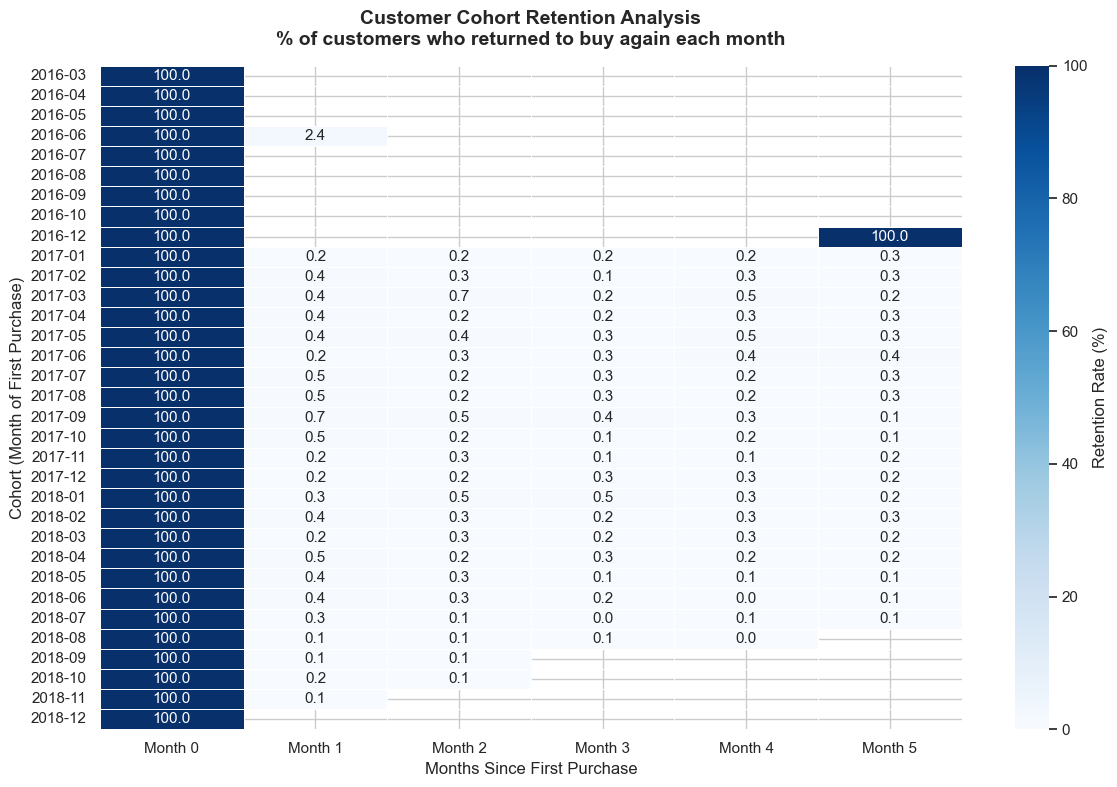

✓ Cohort heatmap saved as cohort_analysis.png


In [13]:
# ---- STEP 10: Plot the retention heatmap ----

fig, ax = plt.subplots(figsize=(12, 8))

# Draw the heatmap
# annot=True shows the actual numbers inside each cell
# fmt='.1f' formats numbers to 1 decimal place
# cmap='Blues' uses blue colour scale (darker = higher retention)
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    vmin=0,
    vmax=100,
    cbar_kws={'label': 'Retention Rate (%)'}
)

# Labels and title
ax.set_title(
    'Customer Cohort Retention Analysis\n'
    '% of customers who returned to buy again each month',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cohort (Month of First Purchase)', fontsize=12)

# Column headers - rename 0,1,2 to "Month 0", "Month 1" etc.
ax.set_xticklabels([f'Month {i}' for i in range(retention_matrix.shape[1])])

plt.tight_layout()
plt.savefig('cohort_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Cohort heatmap saved as cohort_analysis.png")

In [14]:
# ---- Print key business insights from cohort analysis ----

print("=" * 50)
print("  COHORT ANALYSIS — KEY INSIGHTS")
print("=" * 50)

# Average retention at Month 1 (first return purchase)
month1_retention = retention_matrix[1].mean()
print(f"\nAverage Month 1 retention rate : {month1_retention:.1f}%")
print(f"(This means only {month1_retention:.1f}% of customers bought again the next month)")

# Best performing cohort
best_cohort = retention_matrix[1].idxmax()
best_rate   = retention_matrix[1].max()
print(f"\nBest retention cohort : {best_cohort} ({best_rate:.1f}% returned in Month 1)")

# Worst performing cohort
worst_cohort = retention_matrix[1].idxmin()
worst_rate   = retention_matrix[1].min()
print(f"Worst retention cohort: {worst_cohort} ({worst_rate:.1f}% returned in Month 1)")

print(f"""
BUSINESS INTERPRETATION:
- A high Month 0 number (100%) is expected — that's their first purchase
- Month 1 retention below 10% means most customers never return
- This suggests the business relies heavily on NEW customer acquisition
- Recommendation: introduce loyalty programmes and re-engagement campaigns
  to improve repeat purchase rate
""")

  COHORT ANALYSIS — KEY INSIGHTS

Average Month 1 retention rate : 0.4%
(This means only 0.4% of customers bought again the next month)

Best retention cohort : 2016-06 (2.4% returned in Month 1)
Worst retention cohort: 2018-08 (0.1% returned in Month 1)

BUSINESS INTERPRETATION:
- A high Month 0 number (100%) is expected — that's their first purchase
- Month 1 retention below 10% means most customers never return
- This suggests the business relies heavily on NEW customer acquisition
- Recommendation: introduce loyalty programmes and re-engagement campaigns
  to improve repeat purchase rate



## Section 5: Funnel Analysis

A funnel shows how many customers make it through each stage of a process.
At each stage some customers drop off — the funnel gets narrower.

**Business question: Where in the order process do we lose the most customers?**

Our order process funnel:
1. Order Placed     → customer placed an order
2. Order Approved   → payment was confirmed
3. Order Shipped    → seller handed to carrier
4. Order Delivered  → customer received the item
5. Order Reviewed   → customer left a review

In [15]:
# ============================================================
# SECTION 5: FUNNEL ANALYSIS
# ============================================================

# ---- STEP 1: Count orders at each stage ----
# We count how many orders made it to each step

# Stage 1: Total orders placed (all orders regardless of status)
stage1 = orders.shape[0]

# Stage 2: Orders that were approved (approved_at column is not empty)
stage2 = orders['order_approved_at'].notna().sum()

# Stage 3: Orders that were shipped or delivered
stage3 = orders[orders['order_status'].isin(['shipped', 'delivered'])].shape[0]

# Stage 4: Orders successfully delivered
stage4 = orders[orders['order_status'] == 'delivered'].shape[0]

# Stage 5: Orders that received a customer review
stage5 = reviews['order_id'].nunique()

# ---- STEP 2: Build a clean dataframe ----
funnel_df = pd.DataFrame({
    'stage'       : ['1. Order Placed', '2. Order Approved',
                     '3. Order Shipped', '4. Order Delivered',
                     '5. Order Reviewed'],
    'order_count' : [stage1, stage2, stage3, stage4, stage5]
})

# ---- STEP 3: Calculate drop-off at each stage ----
# Drop-off = how many orders were lost compared to previous stage
funnel_df['drop_off'] = funnel_df['order_count'].shift(1) - funnel_df['order_count']
funnel_df['drop_off'] = funnel_df['drop_off'].fillna(0).astype(int)

# ---- STEP 4: Calculate conversion rates ----
# vs previous stage - how much did we keep from last step
funnel_df['conv_from_prev'] = (
    funnel_df['order_count'] / funnel_df['order_count'].shift(1) * 100
).round(1)

# vs first stage - overall funnel progress
funnel_df['conv_from_top'] = (
    funnel_df['order_count'] / stage1 * 100
).round(1)

# First stage has no previous stage so set to 100%
funnel_df.loc[0, 'conv_from_prev'] = 100.0

# ---- STEP 5: Print the funnel table ----
print("ORDER PROCESSING FUNNEL")
print("=" * 70)
print(f"{'Stage':<22} {'Orders':>9} {'Drop-off':>10} {'vs Prev':>9} {'vs Start':>9}")
print("-" * 70)

for _, row in funnel_df.iterrows():
    print(
        f"{row['stage']:<22}"
        f"{row['order_count']:>9,}"
        f"{row['drop_off']:>10,}"
        f"{row['conv_from_prev']:>8.1f}%"
        f"{row['conv_from_top']:>8.1f}%"
    )

ORDER PROCESSING FUNNEL
Stage                     Orders   Drop-off   vs Prev  vs Start
----------------------------------------------------------------------
1. Order Placed          99,441         0   100.0%   100.0%
2. Order Approved        99,281       160    99.8%    99.8%
3. Order Shipped         97,585     1,696    98.3%    98.1%
4. Order Delivered       96,478     1,107    98.9%    97.0%
5. Order Reviewed        98,673    -2,195   102.3%    99.2%


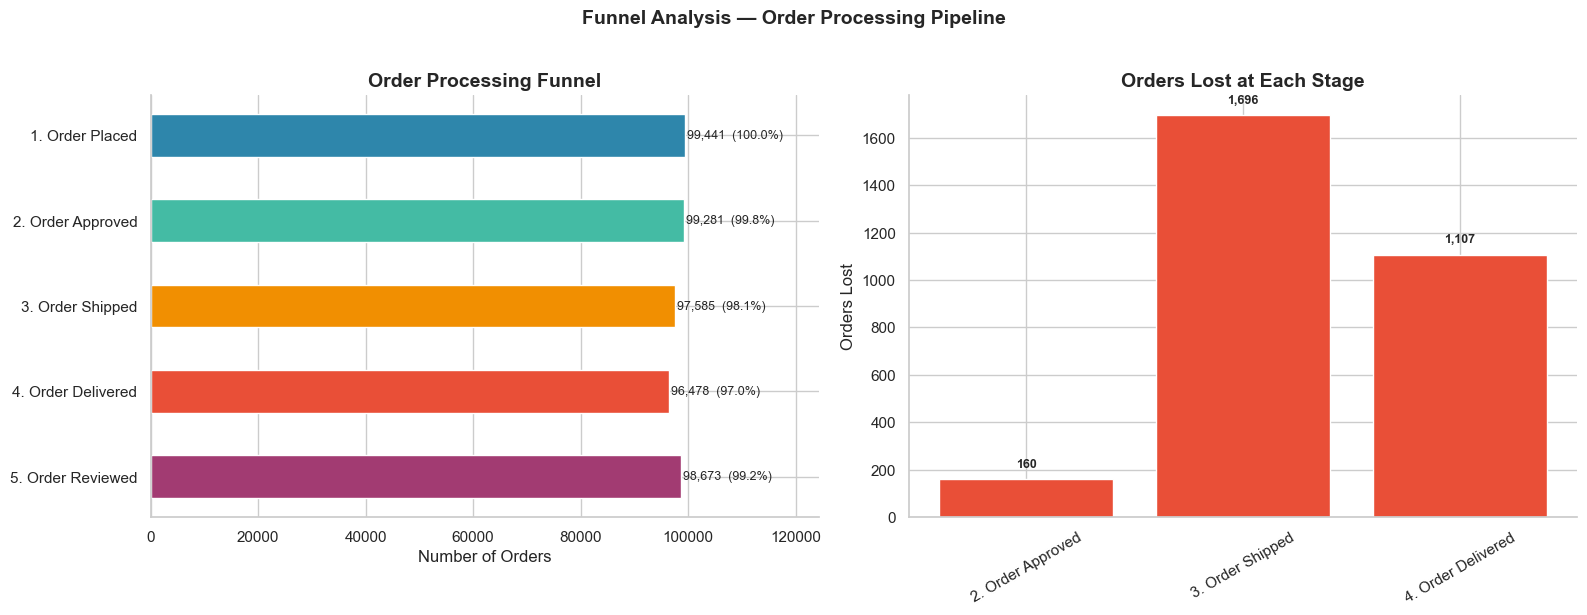

✓ Funnel chart saved as funnel_analysis.png


In [16]:
# ---- STEP 6: Plot the funnel as a horizontal bar chart ----

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT CHART: Funnel bar chart ---
bar_colors = ['#2E86AB', '#44BBA4', '#F18F01', '#E94F37', '#A23B72']

bars = axes[0].barh(
    funnel_df['stage'],
    funnel_df['order_count'],
    color=bar_colors,
    height=0.5,
    edgecolor='white'
)

# Add count and percentage labels to each bar
for bar, row in zip(bars, funnel_df.itertuples()):
    label = f"{row.order_count:,}  ({row.conv_from_top:.1f}%)"
    axes[0].text(
        bar.get_width() + 300,        # position: just right of bar end
        bar.get_y() + bar.get_height() / 2,  # vertical centre of bar
        label,
        va='center',
        fontsize=9
    )

axes[0].set_title('Order Processing Funnel', fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].invert_yaxis()  # Stage 1 at top, Stage 5 at bottom
axes[0].set_xlim(0, stage1 * 1.25)  # extra space for labels

# Remove top and right borders for cleaner look
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- RIGHT CHART: Drop-off at each stage ---
# Skip first row (no drop-off at stage 1)
dropoff_data = funnel_df[funnel_df['drop_off'] > 0].copy()

axes[1].bar(
    dropoff_data['stage'],
    dropoff_data['drop_off'],
    color='#E94F37',
    edgecolor='white'
)

# Add labels on top of each bar
for i, row in enumerate(dropoff_data.itertuples()):
    axes[1].text(
        i,
        row.drop_off + 50,
        f"{row.drop_off:,}",
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

axes[1].set_title('Orders Lost at Each Stage', fontweight='bold')
axes[1].set_ylabel('Orders Lost')
axes[1].tick_params(axis='x', rotation=30)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Funnel Analysis — Order Processing Pipeline',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('funnel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Funnel chart saved as funnel_analysis.png")

In [18]:
# ---- Print key business insights from funnel analysis ----

# Find the stage with the biggest drop-off
biggest_dropoff_idx = funnel_df['drop_off'].idxmax()
biggest_dropoff_stage = funnel_df.loc[biggest_dropoff_idx, 'stage']
biggest_dropoff_count = funnel_df.loc[biggest_dropoff_idx, 'drop_off']

print("=" * 50)
print("  FUNNEL ANALYSIS — KEY INSIGHTS")
print("=" * 50)

for _, row in funnel_df.iterrows():
    print(f"{row['stage']:<22}: {row['order_count']:>7,} orders "
          f"({row['conv_from_top']:.1f}% of total)")

print(f"""
BIGGEST DROP-OFF:
  Stage : {biggest_dropoff_stage}
  Lost  : {biggest_dropoff_count:,} orders

BUSINESS INTERPRETATION:
- Orders placed vs approved gap = payment failures or fraud blocks
- Approved vs shipped gap       = seller fulfilment delays
- Shipped vs delivered gap      = carrier/logistics failures  
- Delivered vs reviewed gap     = low review engagement
  
The biggest drop-off stage is highest priority for process improvement.
This finding directly feeds into the BPMN TO-BE diagram.
""")

  FUNNEL ANALYSIS — KEY INSIGHTS
1. Order Placed       :  99,441 orders (100.0% of total)
2. Order Approved     :  99,281 orders (99.8% of total)
3. Order Shipped      :  97,585 orders (98.1% of total)
4. Order Delivered    :  96,478 orders (97.0% of total)
5. Order Reviewed     :  98,673 orders (99.2% of total)

BIGGEST DROP-OFF:
  Stage : 3. Order Shipped
  Lost  : 1,696 orders

BUSINESS INTERPRETATION:
- Orders placed vs approved gap = payment failures or fraud blocks
- Approved vs shipped gap       = seller fulfilment delays
- Shipped vs delivered gap      = carrier/logistics failures  
- Delivered vs reviewed gap     = low review engagement
  
The biggest drop-off stage is highest priority for process improvement.
This finding directly feeds into the BPMN TO-BE diagram.

